# Akshar Farm And Nursery: Sales, Seasonality and Production Analysis

**Business:** Akshar Farm And Nursery, Jesapura Mithapura (Ta. Thasra, Dist. Kheda, Gujarat).
A seedling nursery raising F1 hybrid chilli, capsicum, tomato, brinjal, marigold and tobacco seedlings
in plastic pro-trays and nursery beds, selling to retail farmers, dealers and home gardeners.

> **About the data.** The business, crops, seed varieties, methods, hours and villages are real.
> The **transaction data is simulated** (`src/generate_data.py`, fixed random seed) from documented
> assumptions, because the nursery keeps paper records. The analysis pipeline is built so the real
> sales log (`data/templates/daily_sales_log_template.csv`) can replace it without code changes.

### Business questions
1. How big is the business, and is it growing?
2. When is demand highest for each crop, so seed can be bought and sown on time?
3. Which crops and varieties drive revenue and profit?
4. Are farmers moving from nursery-bed to pro-tray seedlings?
5. Who are the customers, where are they, and do they come back?
6. How efficient is production: germination, unsold seedlings and margin?
7. How much should be sown for the rest of the 2026 season?

In [1]:
import json, sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA = Path("../data")
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
REPORTS = Path("../reports")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

BRAND = {"soil": "#4A3426", "leaf": "#4F7F2A", "leaf2": "#86B04A",
         "marigold": "#E39B12", "chilli": "#B8322A", "muted": "#8A7F6E"}
CROP_COLORS = {"Chilli": "#B8322A", "Tomato": "#E0603A", "Capsicum": "#2F7D32",
               "Brinjal": "#5B2C6F", "Marigold": "#E39B12", "Tobacco": "#8A7F6E"}
YEAR_COLORS = {2024: "#C9BFAE", 2025: "#86B04A", 2026: "#4A3426"}
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.titlelocation": "left", "axes.labelcolor": "#4A3F33",
    "font.size": 10.5, "axes.grid": True, "grid.alpha": .25, "axes.axisbelow": True,
    "xtick.color": "#4A3F33", "ytick.color": "#4A3F33",
})

def lakh(x):
    return f"₹{x / 1e5:,.1f} L"

lakh_fmt = mtick.FuncFormatter(lambda x, _: f"₹{x / 1e5:,.0f}L")

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

## 1. Load and check the data

In [2]:
orders = pd.read_csv(DATA / "raw/orders.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA / "raw/customers.csv", parse_dates=["first_order_date"])
varieties = pd.read_csv(DATA / "raw/varieties.csv")
batches = pd.read_csv(DATA / "raw/production_batches.csv", parse_dates=["sow_date", "ready_from"])

orders["year"] = orders.order_date.dt.year
orders["month"] = orders.order_date.dt.month
orders["ym"] = orders.order_date.dt.to_period("M")
orders = orders.merge(varieties[["variety_id", "variety", "brand"]], on="variety_id", how="left")

pd.DataFrame({"rows": [len(orders), len(customers), len(varieties), len(batches)]},
             index=["orders", "customers", "varieties", "production_batches"])

,rows
orders,6824
customers,3001
varieties,16
production_batches,846


In [3]:
expected = orders.quantity * orders.unit_price_inr * (1 - orders.discount_pct / 100)
checks = pd.DataFrame({
    "check": [
        "Missing values in orders",
        "Duplicate order IDs",
        "Orders with an unknown customer",
        "Orders with an unknown variety",
        "Zero or negative quantity / price",
        "Revenue != quantity x price x (1 - discount)",
        "Batches where sold > ready",
    ],
    "rows_failing": [
        int(orders.drop(columns=["variety", "brand"]).isna().sum().sum()),
        int(orders.order_id.duplicated().sum()),
        int((~orders.customer_id.isin(customers.customer_id)).sum()),
        int((~orders.variety_id.isin(varieties.variety_id)).sum()),
        int(((orders.quantity <= 0) | (orders.unit_price_inr <= 0)).sum()),
        int((~np.isclose(orders.revenue_inr, expected, atol=0.05)).sum()),
        int((batches.seedlings_sold > batches.seedlings_ready).sum()),
    ],
})
checks["status"] = np.where(checks.rows_failing == 0, "PASS", "CHECK")
checks

,check,rows_failing,status
0,Missing values in orders,0,PASS
1,Duplicate order IDs,0,PASS
2,Orders with an unknown customer,0,PASS
3,Orders with an unknown variety,0,PASS
4,Zero or negative quantity / price,0,PASS
5,Revenue != quantity x price x (1 - discount),0,PASS
6,Batches where sold > ready,0,PASS


In [4]:
print("Date range:", orders.order_date.min().date(), "to", orders.order_date.max().date())
print("2026 is a partial year (January to August), so year-on-year comparisons use Jan to Aug only.")

Date range: 2024-01-01 to 2026-08-31
2026 is a partial year (January to August), so year-on-year comparisons use Jan to Aug only.


## 2. Headline KPIs

In [5]:
def period(df, year):
    return df[(df.year == year) & (df.month <= 8)]

ytd25, ytd26 = period(orders, 2025), period(orders, 2026)
annual = orders.groupby("year").agg(revenue=("revenue_inr", "sum"), seedlings=("quantity", "sum"),
                                    orders=("order_id", "count"), customers=("customer_id", "nunique"))
annual["avg_order_value"] = annual.revenue / annual.orders

kpis = {
    "total_revenue": float(orders.revenue_inr.sum()),
    "total_seedlings": int(orders.quantity.sum()),
    "total_orders": int(len(orders)),
    "total_customers": int(orders.customer_id.nunique()),
    "avg_order_value": float(orders.revenue_inr.mean()),
    "revenue_2024": float(annual.loc[2024, "revenue"]),
    "revenue_2025": float(annual.loc[2025, "revenue"]),
    "growth_2025_vs_2024_pct": float(100 * (annual.loc[2025, "revenue"] / annual.loc[2024, "revenue"] - 1)),
    "ytd_revenue_2026": float(ytd26.revenue_inr.sum()),
    "ytd_growth_2026_vs_2025_pct": float(100 * (ytd26.revenue_inr.sum() / ytd25.revenue_inr.sum() - 1)),
}
for k, v in kpis.items():
    shown = lakh(v) if "revenue" in k and "pct" not in k else f"{v:,.1f}%" if k.endswith("pct") else f"{v:,.0f}"
    print(f"{k:<32} {shown}")
annual.style.format({"revenue": lakh, "seedlings": "{:,.0f}", "avg_order_value": "₹{:,.0f}"})

total_revenue                    ₹228.4 L
total_seedlings                  28,260,340
total_orders                     6,824
total_customers                  3,001
avg_order_value                  3,347
revenue_2024                     ₹67.4 L
revenue_2025                     ₹84.2 L
growth_2025_vs_2024_pct          24.9%
ytd_revenue_2026                 ₹76.7 L
ytd_growth_2026_vs_2025_pct      33.0%


,revenue,seedlings,orders,customers,avg_order_value
year,,,,,
2024,₹67.4 L,"9,339,490",2195,953,"₹3,073"
2025,₹84.2 L,"10,798,040",2602,1740,"₹3,238"
2026,₹76.7 L,"8,122,810",2027,1632,"₹3,785"


## 3. Seasonality: when do farmers buy?
Seedlings must be sown 25 to 48 days before they are sold, so the nursery has to know the demand calendar
more than a month in advance.

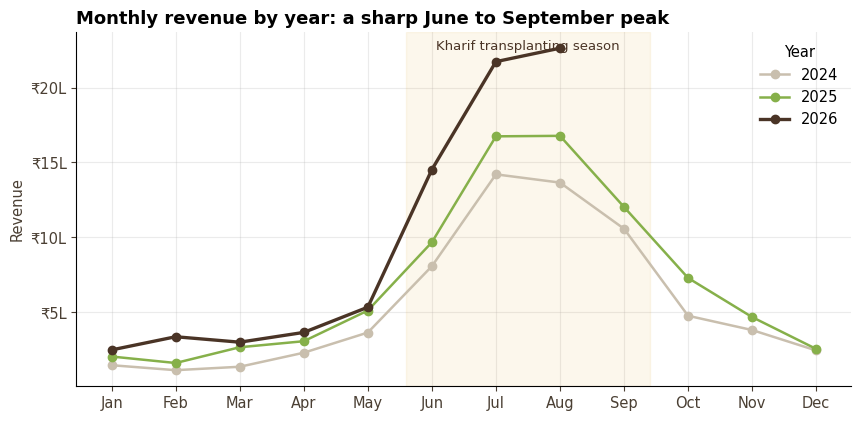

In [6]:
m = orders.groupby(["year", "month"]).revenue_inr.sum().unstack(0)
fig, ax = plt.subplots(figsize=(10, 4.6))
for y in m.columns:
    ax.plot(m.index, m[y], marker="o", lw=2.4 if y == 2026 else 1.8, color=YEAR_COLORS[y], label=str(y))
ax.set_xticks(range(1, 13), MONTHS)
ax.yaxis.set_major_formatter(lakh_fmt)
ax.set_title("Monthly revenue by year: a sharp June to September peak")
ax.set_ylabel("Revenue")
ax.legend(frameon=False, title="Year")
ax.axvspan(5.6, 9.4, color=BRAND["marigold"], alpha=.08)
ax.text(7.5, ax.get_ylim()[1] * .95, "Kharif transplanting season", ha="center", color=BRAND["soil"], fontsize=9.5)
save(fig, "01_monthly_revenue_by_year")

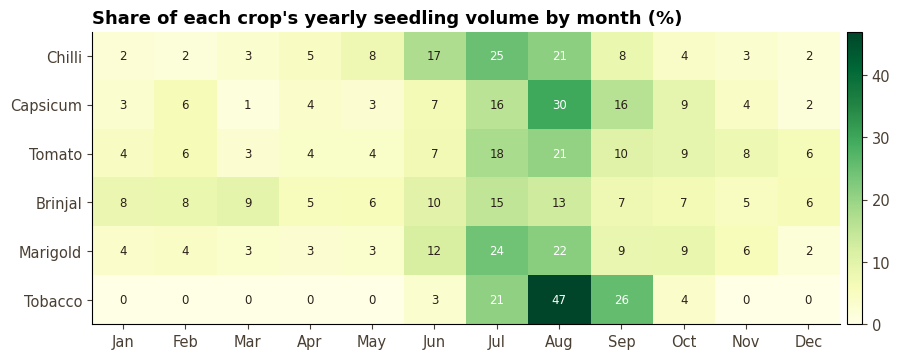

,peak_month,share_in_peak_month_pct,top_3_months_share_pct
crop,,,
Chilli,Jul,24.9,63.4
Capsicum,Aug,29.5,61.5
Tomato,Aug,20.5,48.8
Brinjal,Jul,15.0,38.1
Marigold,Jul,24.3,57.7
Tobacco,Aug,47.0,93.3


In [7]:
seas = orders.groupby(["crop", "month"]).quantity.sum().unstack(fill_value=0)
seas = seas.div(seas.sum(axis=1), axis=0) * 100          # % of each crop's yearly volume by month
order = ["Chilli", "Capsicum", "Tomato", "Brinjal", "Marigold", "Tobacco"]
seas = seas.loc[order]
fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(seas.values, cmap="YlGn", aspect="auto")
ax.set_xticks(range(12), MONTHS); ax.set_yticks(range(len(order)), order); ax.grid(False)
for i in range(seas.shape[0]):
    for j in range(12):
        v = seas.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5, color="white" if v > 18 else "#2A2019")
ax.set_title("Share of each crop's yearly seedling volume by month (%)")
fig.colorbar(im, ax=ax, fraction=.025, pad=.01)
save(fig, "02_seasonality_heatmap")

peak = pd.DataFrame({
    "peak_month": seas.idxmax(axis=1).map(lambda x: MONTHS[x - 1]),
    "share_in_peak_month_pct": seas.max(axis=1).round(1),
    "top_3_months_share_pct": seas.apply(lambda r: r.nlargest(3).sum(), axis=1).round(1),
})
peak

## 4. Crops and varieties

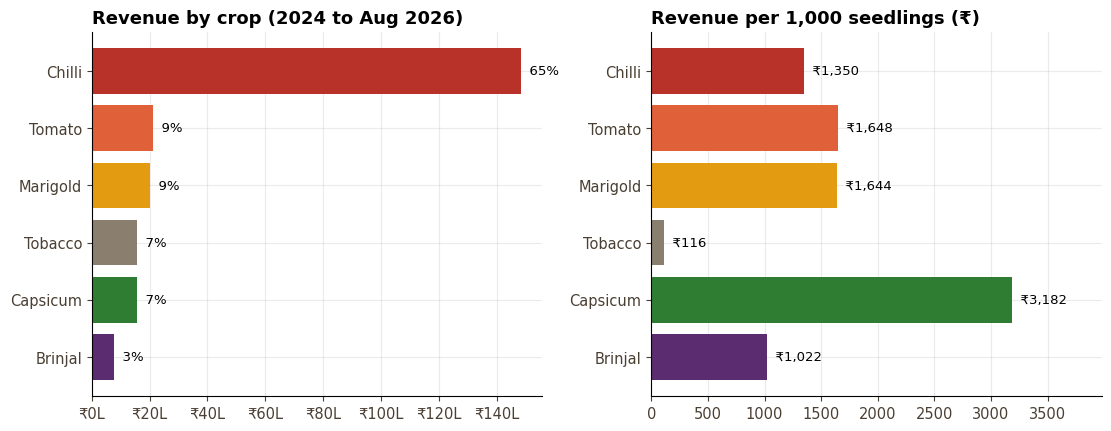

,revenue,seedlings,revenue_share_pct,revenue_per_1000_seedlings
crop,,,,
Chilli,₹148.2 L,"10,983,310",64.9,"₹1,350"
Tomato,₹21.1 L,"1,281,850",9.3,"₹1,648"
Marigold,₹20.1 L,"1,224,500",8.8,"₹1,644"
Tobacco,₹15.7 L,"13,531,800",6.9,₹116
Capsicum,₹15.5 L,"488,740",6.8,"₹3,182"
Brinjal,₹7.7 L,"750,140",3.4,"₹1,022"


In [8]:
crop = orders.groupby("crop").agg(revenue=("revenue_inr", "sum"), seedlings=("quantity", "sum")).sort_values("revenue")
crop["revenue_share_pct"] = 100 * crop.revenue / crop.revenue.sum()
crop["revenue_per_1000_seedlings"] = 1000 * crop.revenue / crop.seedlings

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
axes[0].barh(crop.index, crop.revenue, color=[CROP_COLORS[c] for c in crop.index])
axes[0].xaxis.set_major_formatter(lakh_fmt)
for i, (r, s) in enumerate(zip(crop.revenue, crop.revenue_share_pct)):
    axes[0].text(r, i, f"  {s:.0f}%", va="center", fontsize=9.5)
axes[0].set_title("Revenue by crop (2024 to Aug 2026)")
axes[1].barh(crop.index, crop.revenue_per_1000_seedlings, color=[CROP_COLORS[c] for c in crop.index])
axes[1].set_title("Revenue per 1,000 seedlings (₹)")
for i, v in enumerate(crop.revenue_per_1000_seedlings):
    axes[1].text(v, i, f"  ₹{v:,.0f}", va="center", fontsize=9.5)
axes[1].set_xlim(0, crop.revenue_per_1000_seedlings.max() * 1.25)
save(fig, "03_crop_revenue")
crop.sort_values("revenue", ascending=False).style.format(
    {"revenue": lakh, "seedlings": "{:,.0f}", "revenue_share_pct": "{:.1f}", "revenue_per_1000_seedlings": "₹{:,.0f}"})

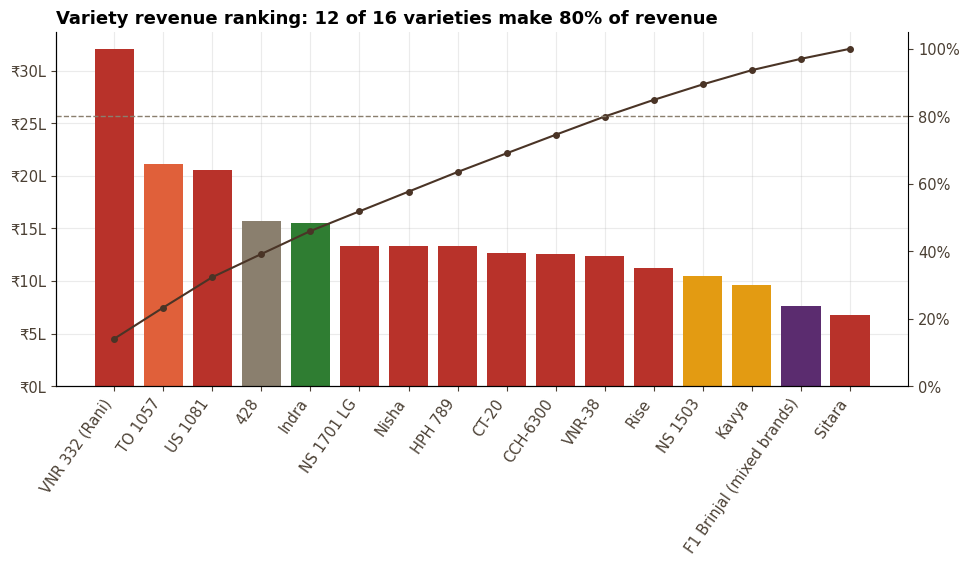

,variety,crop,brand,revenue_inr,cum_share
0,VNR 332 (Rani),Chilli,VNR Seeds,₹32.1 L,14.0%
1,TO 1057,Tomato,Syngenta,₹21.1 L,23.3%
2,US 1081,Chilli,BASF Nunhems,₹20.6 L,32.3%
3,428,Tobacco,Local selection,₹15.7 L,39.2%
4,Indra,Capsicum,Syngenta,₹15.5 L,46.0%
5,NS 1701 LG,Chilli,Namdhari Seeds,₹13.4 L,51.8%
6,Nisha,Chilli,Thakar Seed,₹13.3 L,57.7%
7,HPH 789,Chilli,Syngenta,₹13.3 L,63.5%


In [9]:
v = (orders.groupby(["variety", "crop", "brand"]).revenue_inr.sum()
     .sort_values(ascending=False).reset_index())
v["cum_share"] = 100 * v.revenue_inr.cumsum() / v.revenue_inr.sum()
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(v.variety, v.revenue_inr, color=[CROP_COLORS[c] for c in v.crop])
ax.yaxis.set_major_formatter(lakh_fmt)
ax.tick_params(axis="x", rotation=55)
plt.setp(ax.get_xticklabels(), ha="right")
ax2 = ax.twinx(); ax2.plot(v.variety, v.cum_share, color=BRAND["soil"], marker="o", ms=4)
ax2.set_ylim(0, 105); ax2.yaxis.set_major_formatter(mtick.PercentFormatter()); ax2.grid(False)
ax2.axhline(80, ls="--", lw=1, color=BRAND["muted"])
ax2.spines["right"].set_visible(True)
n80 = int((v.cum_share < 80).sum()) + 1
ax.set_title(f"Variety revenue ranking: {n80} of {len(v)} varieties make 80% of revenue")
save(fig, "04_variety_pareto")
v.head(8).style.format({"revenue_inr": lakh, "cum_share": "{:.1f}%"})

## 5. Are farmers moving to pro-tray seedlings?

Chilli pro-tray share: 58% (2024) -> 71% (2026)


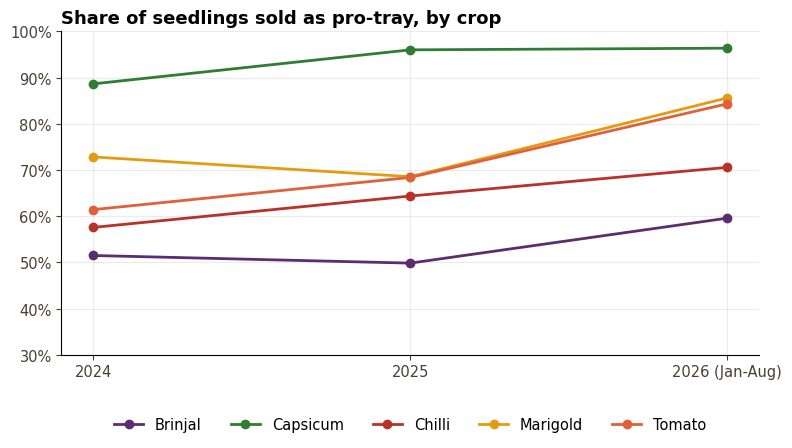

method,Nursery bed,Pro-tray,protray_premium_pct
crop,,,
Brinjal,0.805882,1.212945,51%
Capsicum,2.320156,3.237647,40%
Chilli,1.056192,1.513205,43%
Marigold,1.275707,1.764991,38%
Tomato,1.252093,1.816852,45%


In [10]:
pt = (orders[orders.crop != "Tobacco"]
      .assign(pt_qty=lambda d: np.where(d.method == "Pro-tray", d.quantity, 0))
      .groupby(["crop", "year"])[["pt_qty", "quantity"]].sum())
pt["protray_share"] = 100 * pt.pt_qty / pt.quantity
share = pt.protray_share.unstack(0)

price = (orders[orders.crop != "Tobacco"].groupby(["crop", "method"]).apply(
    lambda d: d.revenue_inr.sum() / d.quantity.sum(), include_groups=False).unstack())
price["protray_premium_pct"] = 100 * (price["Pro-tray"] / price["Nursery bed"] - 1)

fig, ax = plt.subplots(figsize=(9, 4.2))
for c in share.columns:
    ax.plot(share.index, share[c], marker="o", lw=2, color=CROP_COLORS[c], label=c)
ax.set_xticks([2024, 2025, 2026], ["2024", "2025", "2026 (Jan-Aug)"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylim(30, 100)
ax.set_title("Share of seedlings sold as pro-tray, by crop")
ax.legend(frameon=False, ncol=5, loc="lower center", bbox_to_anchor=(.5, -.28))
save(fig, "05_protray_adoption")
chilli_pt = share["Chilli"]
print(f"Chilli pro-tray share: {chilli_pt[2024]:.0f}% (2024) -> {chilli_pt[2026]:.0f}% (2026)")
price.style.format("{:.2f}").format({"protray_premium_pct": "{:.0f}%"})

## 6. Customers: who buys, from where, and do they return?

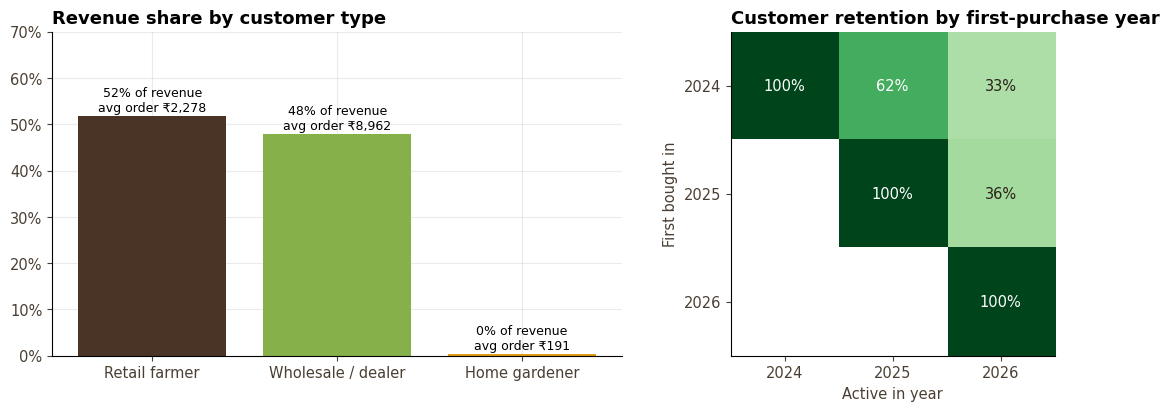

,orders,customers,revenue,aov,revenue_share_pct,orders_per_customer
customer_type,,,,,,
Retail farmer,5185,2371,₹118.1 L,"₹2,278",51.7,2.19
Wholesale / dealer,1222,318,₹109.5 L,"₹8,962",47.9,3.84
Home gardener,417,312,₹0.8 L,₹191,0.3,1.34


In [11]:
seg = orders.groupby("customer_type").agg(orders=("order_id", "count"), customers=("customer_id", "nunique"),
                                          revenue=("revenue_inr", "sum"), aov=("revenue_inr", "mean"))
seg["revenue_share_pct"] = 100 * seg.revenue / seg.revenue.sum()
seg["orders_per_customer"] = seg.orders / seg.customers
seg = seg.sort_values("revenue", ascending=False)

first = orders.groupby("customer_id").year.min().rename("cohort")
act = orders[["customer_id", "year"]].drop_duplicates().join(first, on="customer_id")
coh = act.pivot_table(index="cohort", columns="year", values="customer_id", aggfunc="nunique")
ret = coh.div(coh.values.diagonal(), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), layout="constrained", gridspec_kw={"width_ratios": [1.1, 1]})
cols = [BRAND["soil"], BRAND["leaf2"], BRAND["marigold"]]
axes[0].bar(seg.index, seg.revenue_share_pct, color=cols)
for i, (s, a) in enumerate(zip(seg.revenue_share_pct, seg.aov)):
    axes[0].text(i, s + 1, f"{s:.0f}% of revenue\navg order ₹{a:,.0f}", ha="center", fontsize=9)
axes[0].set_ylim(0, 70); axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("Revenue share by customer type")
im = axes[1].imshow(ret.values, cmap="Greens", vmin=0, vmax=100); axes[1].grid(False)
axes[1].set_xticks(range(ret.shape[1]), ret.columns); axes[1].set_yticks(range(ret.shape[0]), ret.index)
for i in range(ret.shape[0]):
    for j in range(ret.shape[1]):
        val = ret.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f"{val:.0f}%", ha="center", va="center", color="white" if val > 60 else "#2A2019")
axes[1].set_xlabel("Active in year"); axes[1].set_ylabel("First bought in")
axes[1].set_title("Customer retention by first-purchase year")
save(fig, "06_customer_segments")
seg.style.format({"revenue": lakh, "aov": "₹{:,.0f}", "revenue_share_pct": "{:.1f}", "orders_per_customer": "{:.2f}"})

Customers more than 30 km away bring 31% of farm and dealer revenue.


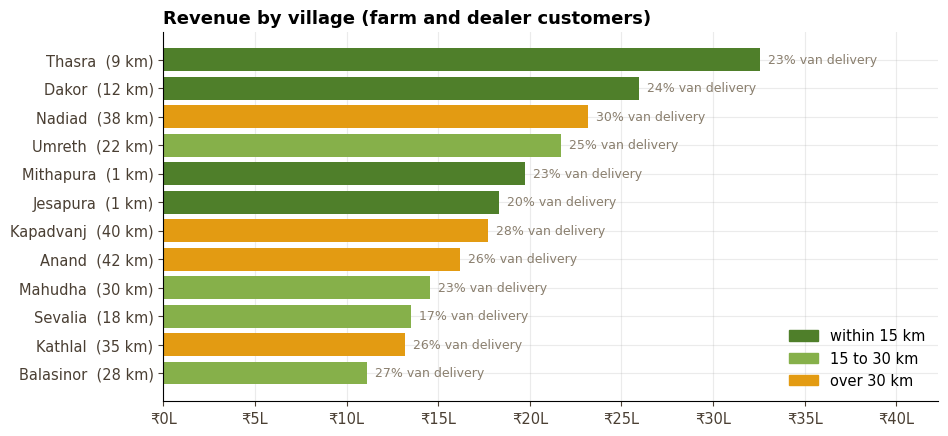

In [12]:
geo = (orders[orders.customer_type != "Home gardener"].merge(customers[["customer_id", "village", "distance_km"]], on="customer_id")
       .groupby(["village", "distance_km"]).agg(revenue=("revenue_inr", "sum"), orders=("order_id", "count"),
                                                van=("fulfilment", lambda s: 100 * (s == "Van delivery").mean()))
       .reset_index().sort_values("revenue"))
fig, ax = plt.subplots(figsize=(10, 4.8))
colors = [BRAND["leaf"] if d <= 15 else BRAND["leaf2"] if d <= 30 else BRAND["marigold"] for d in geo.distance_km]
ax.barh(geo.village + "  (" + geo.distance_km.astype(str) + " km)", geo.revenue, color=colors)
ax.xaxis.set_major_formatter(lakh_fmt)
for i, (r, vv) in enumerate(zip(geo.revenue, geo.van)):
    ax.text(r, i, f"  {vv:.0f}% van delivery", va="center", fontsize=9, color=BRAND["muted"])
ax.set_xlim(0, geo.revenue.max() * 1.3)
ax.set_title("Revenue by village (farm and dealer customers)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BRAND["leaf"], label="within 15 km"), Patch(color=BRAND["leaf2"], label="15 to 30 km"),
                   Patch(color=BRAND["marigold"], label="over 30 km")], frameon=False, loc="lower right")
save(fig, "07_village_revenue")
far = geo[geo.distance_km > 30].revenue.sum() / geo.revenue.sum() * 100
print(f"Customers more than 30 km away bring {far:.0f}% of farm and dealer revenue.")

## 7. Production efficiency and margin

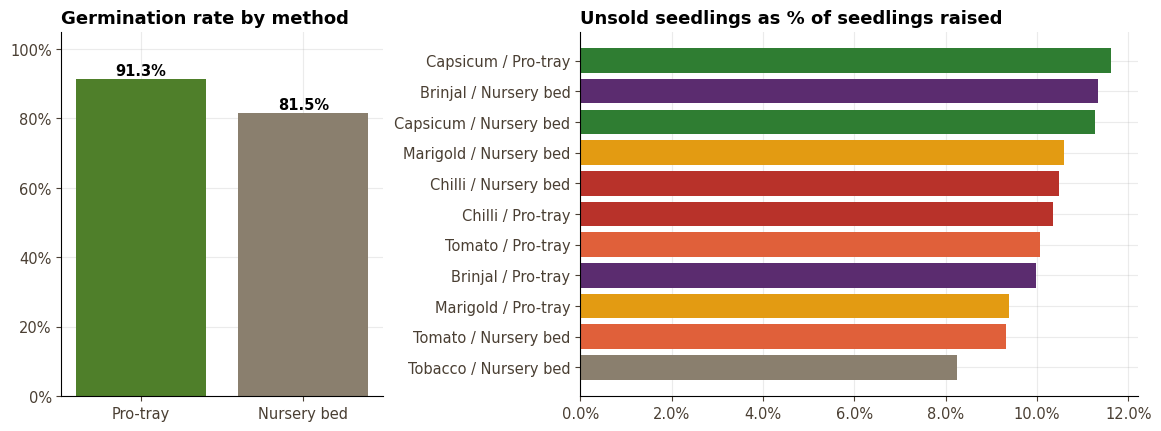

In [13]:
b = batches.merge(varieties[["variety_id", "crop", "variety"]], on="variety_id")
eff = b.groupby(["crop", "method"]).agg(sown=("seeds_sown", "sum"), ready=("seedlings_ready", "sum"),
                                         unsold=("seedlings_unsold", "sum"))
eff["germination_pct"] = 100 * eff.ready / eff.sown
eff["unsold_pct"] = 100 * eff.unsold / eff.ready
g = b.groupby("method").apply(lambda d: 100 * d.seedlings_ready.sum() / d.seeds_sown.sum(), include_groups=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained", gridspec_kw={"width_ratios": [.75, 1.3]})
g = g.reindex(["Pro-tray", "Nursery bed"])
axes[0].bar(g.index, g.values, color=[BRAND["leaf"], BRAND["muted"]])
for i, val in enumerate(g.values):
    axes[0].text(i, val + 1, f"{val:.1f}%", ha="center", fontweight="bold")
axes[0].set_ylim(0, 105); axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("Germination rate by method")
u = eff.reset_index().sort_values("unsold_pct")
axes[1].barh(u.crop + " / " + u.method, u.unsold_pct, color=[CROP_COLORS[c] for c in u.crop])
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Unsold seedlings as % of seedlings raised")
save(fig, "08_production_efficiency")
eff.style.format({"sown": "{:,.0f}", "ready": "{:,.0f}", "unsold": "{:,.0f}", "germination_pct": "{:.1f}", "unsold_pct": "{:.1f}"})

Overall gross margin (after seed and raising cost): 24.2%


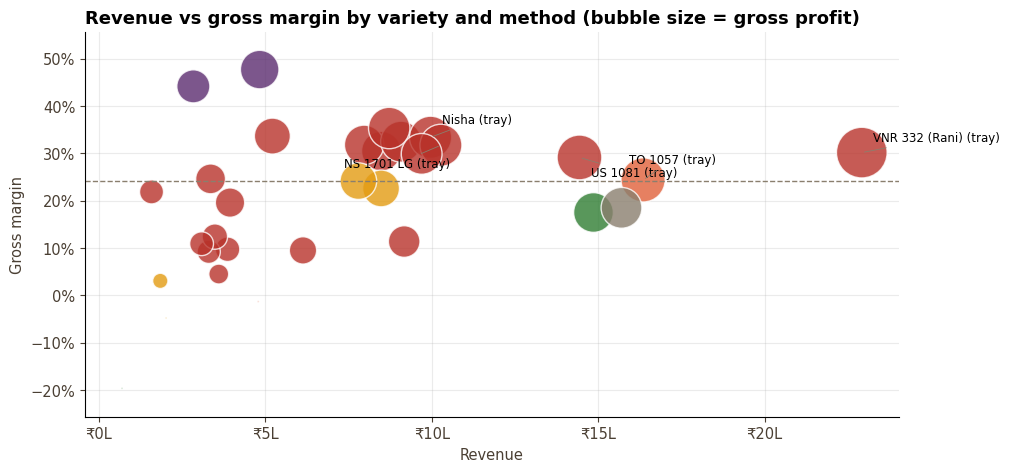

,crop,variety,method,revenue,cost,gross_profit,margin_pct
1,Chilli,VNR 332 (Rani),Pro-tray,₹22.9 L,₹16.0 L,₹6.9 L,30.2%
5,Chilli,US 1081,Pro-tray,₹14.4 L,₹10.2 L,₹4.2 L,29.2%
23,Tomato,TO 1057,Pro-tray,₹16.3 L,₹12.4 L,₹4.0 L,24.4%
13,Chilli,Nisha,Pro-tray,₹10.0 L,₹6.6 L,₹3.3 L,33.4%
15,Chilli,NS 1701 LG,Pro-tray,₹10.3 L,₹7.0 L,₹3.3 L,31.7%
11,Chilli,CT-20,Pro-tray,₹8.7 L,₹5.6 L,₹3.1 L,35.4%
9,Chilli,CCH-6300,Pro-tray,₹9.1 L,₹6.1 L,₹2.9 L,32.5%
30,Tobacco,428,Nursery bed,₹15.7 L,₹12.8 L,₹2.9 L,18.5%
17,Chilli,HPH 789,Pro-tray,₹9.7 L,₹6.8 L,₹2.9 L,29.9%
21,Capsicum,Indra,Pro-tray,₹14.9 L,₹12.3 L,₹2.6 L,17.5%


In [14]:
rev = orders.groupby(["variety_id", "method"]).agg(revenue=("revenue_inr", "sum"), sold=("quantity", "sum"))
cost = batches.assign(cost=batches.seed_cost_inr + batches.raising_cost_inr).groupby(["variety_id", "method"]).cost.sum()
mg = rev.join(cost).reset_index().merge(varieties[["variety_id", "crop", "variety"]], on="variety_id")
mg["gross_profit"] = mg.revenue - mg.cost
mg["margin_pct"] = 100 * mg.gross_profit / mg.revenue
mg["label"] = mg.variety + " (" + mg.method.str.replace("Nursery bed", "bed").str.replace("Pro-tray", "tray") + ")"

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.scatter(mg.revenue, mg.margin_pct, s=np.sqrt(mg.gross_profit.clip(lower=1)) * 1.6,
           c=[CROP_COLORS[c] for c in mg.crop], alpha=.8, edgecolor="white")
offsets = [(8, 8), (8, -14), (-10, 12), (8, 10), (-70, -16)]
for (_, r), off in zip(mg.nlargest(5, "gross_profit").iterrows(), offsets):
    ax.annotate(r.label, (r.revenue, r.margin_pct), xytext=off, textcoords="offset points", fontsize=8.5,
                arrowprops=dict(arrowstyle="-", color=BRAND["muted"], lw=.6))
ax.set_ylim(mg.margin_pct.min() - 6, mg.margin_pct.max() + 8)
ax.xaxis.set_major_formatter(lakh_fmt); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Revenue"); ax.set_ylabel("Gross margin")
ax.set_title("Revenue vs gross margin by variety and method (bubble size = gross profit)")
ax.axhline(100 * mg.gross_profit.sum() / mg.revenue.sum(), ls="--", lw=1, color=BRAND["muted"])
save(fig, "09_margin_by_variety")
overall_margin = 100 * mg.gross_profit.sum() / mg.revenue.sum()
print(f"Overall gross margin (after seed and raising cost): {overall_margin:.1f}%")
mg.sort_values("gross_profit", ascending=False)[["crop", "variety", "method", "revenue", "cost", "gross_profit", "margin_pct"]].head(10).style.format(
    {"revenue": lakh, "cost": lakh, "gross_profit": lakh, "margin_pct": "{:.1f}%"})

## 8. Payments and order channels

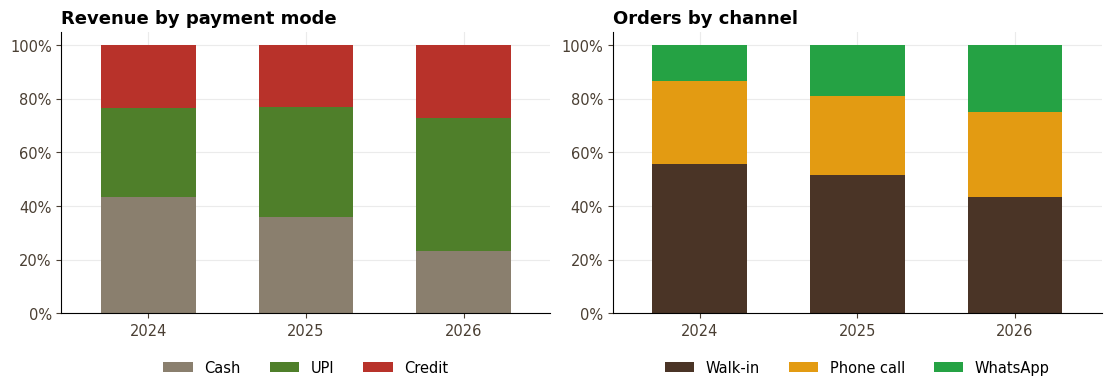

payment_share_%              channel_share_%                 
                Cash Credit   UPI      Phone call Walk-in WhatsApp
year                                                              
2024            43.2   23.5  33.2            30.9    55.8     13.3
2025            36.0   23.1  40.9            29.6    51.5     18.8
2026            23.1   27.1  49.8            31.6    43.4     25.0

In [15]:
pay = orders.pivot_table(index="year", columns="payment_mode", values="revenue_inr", aggfunc="sum")
pay = pay.div(pay.sum(axis=1), axis=0) * 100
chan = orders.pivot_table(index="year", columns="channel", values="order_id", aggfunc="count")
chan = chan.div(chan.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
pay[["Cash", "UPI", "Credit"]].plot(kind="bar", stacked=True, ax=axes[0], rot=0,
                                    color=[BRAND["muted"], BRAND["leaf"], BRAND["chilli"]], width=.6)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter()); axes[0].set_title("Revenue by payment mode")
axes[0].legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(.5, -.12)); axes[0].set_xlabel("")
chan[["Walk-in", "Phone call", "WhatsApp"]].plot(kind="bar", stacked=True, ax=axes[1], rot=0,
                                                 color=[BRAND["soil"], BRAND["marigold"], "#25A244"], width=.6)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter()); axes[1].set_title("Orders by channel")
axes[1].legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(.5, -.12)); axes[1].set_xlabel("")
save(fig, "10_payments_channels")
pd.concat({"payment_share_%": pay.round(1), "channel_share_%": chan.round(1)}, axis=1)

## 9. The same questions in SQL
Every table above can also be answered from the SQLite database (`data/nursery.db`) using the queries in
`sql/analysis_queries.sql`. Two examples, run directly from the file:

In [16]:
con = sqlite3.connect(DATA / "nursery.db")
queries = [q.strip() for q in open("../sql/analysis_queries.sql", encoding="utf-8").read().split(";") if "SELECT" in q]
print(f"{len(queries)} queries loaded from sql/analysis_queries.sql\n")
print("Q6. Customer retention by first-purchase year")
pd.read_sql(queries[5], con)

11 queries loaded from sql/analysis_queries.sql

Q6. Customer retention by first-purchase year


,cohort,new_customers,returned_later,return_rate_pct
0,2024,953,697,73.1
1,2025,1149,418,36.4
2,2026,899,0,0.0


In [17]:
print("Q9. Gross margin by variety and method (top 6)")
pd.read_sql(queries[8], con).head(6)

Q9. Gross margin by variety and method (top 6)


,crop,variety,method,revenue,production_cost,gross_profit,gross_margin_pct,profit_per_seedling
0,Chilli,VNR 332 (Rani),Pro-tray,2291510.0,1600128.0,691382.0,30.2,0.46
1,Chilli,US 1081,Pro-tray,1443501.0,1022704.0,420798.0,29.2,0.48
2,Tomato,TO 1057,Pro-tray,1634531.0,1235641.0,398890.0,24.4,0.44
3,Chilli,Nisha,Pro-tray,996198.0,663416.0,332782.0,33.4,0.42
4,Chilli,NS 1701 LG,Pro-tray,1027291.0,701294.0,325997.0,31.7,0.49
5,Chilli,CT-20,Pro-tray,871962.0,563558.0,308405.0,35.4,0.46


## 10. Sowing plan for September to December 2026
Forecast = last year's seedling volume for the same month x this year's growth for that crop (Jan-Aug 2026 vs
Jan-Aug 2025). Seeds to sow add a 10% safety buffer and divide by the 2026 germination rate.

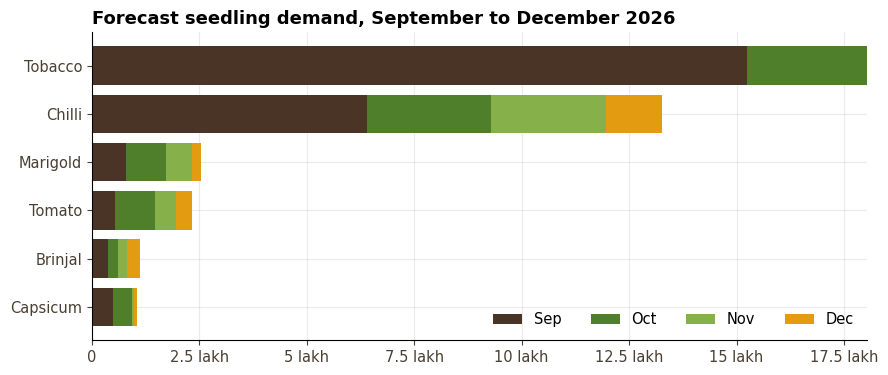

,crop,month,forecast_seedlings,seeds_to_sow,sow_by,growth_vs_2025
0,Chilli,Sep,"641,000","810,300",31 Jul,+26%
1,Chilli,Oct,"286,700","362,300",30 Aug,+26%
2,Chilli,Nov,"268,500","339,400",30 Sep,+26%
3,Chilli,Dec,"131,000","165,600",30 Oct,+26%
4,Capsicum,Sep,"48,500","57,500",25 Jul,+18%
5,Capsicum,Oct,"44,200","52,400",24 Aug,+18%
6,Capsicum,Nov,"6,100","7,300",24 Sep,+18%
7,Capsicum,Dec,"5,600","6,600",24 Oct,+18%
8,Tomato,Sep,"53,600","66,800",06 Aug,+19%
9,Tomato,Oct,"93,100","116,000",05 Sep,+19%


In [18]:
vol = orders.groupby(["crop", "year", "month"]).quantity.sum()
growth = {c: vol[c][2026][vol[c][2026].index <= 8].sum() / vol[c][2025][vol[c][2025].index <= 8].sum()
          for c in orders.crop.unique()}
germ26 = (b[b.ready_from.dt.year == 2026].groupby("crop")
          .apply(lambda d: d.seedlings_ready.sum() / d.seeds_sown.sum(), include_groups=False))
lead = varieties.groupby("crop").days_to_ready.mean()

plan = []
for c in ["Chilli", "Capsicum", "Tomato", "Brinjal", "Marigold", "Tobacco"]:
    for mo in [9, 10, 11, 12]:
        base = vol.get((c, 2025, mo), 0)
        if base == 0:
            continue
        demand = base * growth[c]
        plan.append({"crop": c, "month": MONTHS[mo - 1], "forecast_seedlings": round(demand, -2),
                     "seeds_to_sow": round(demand * 1.10 / germ26[c], -2),
                     "sow_by": (pd.Timestamp(2026, mo, 1) - pd.Timedelta(days=int(lead[c]))).strftime("%d %b"),
                     "growth_vs_2025": f"{100 * (growth[c] - 1):+.0f}%"})
plan = pd.DataFrame(plan)

pv = plan.pivot(index="crop", columns="month", values="forecast_seedlings").reindex(columns=["Sep", "Oct", "Nov", "Dec"]).fillna(0)
pv = pv.loc[pv.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(10, 4))
left = np.zeros(len(pv))
for mo, col in zip(pv.columns, [BRAND["soil"], BRAND["leaf"], BRAND["leaf2"], BRAND["marigold"]]):
    ax.barh(pv.index, pv[mo], left=left, color=col, label=mo); left += pv[mo].values
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x / 1e5:g} lakh" if x else "0"))
ax.set_title("Forecast seedling demand, September to December 2026")
ax.legend(frameon=False, ncol=4, loc="lower right")
save(fig, "11_demand_plan")
plan.style.format({"forecast_seedlings": "{:,.0f}", "seeds_to_sow": "{:,.0f}"})

## 11. Key findings and recommendations

In [19]:
top_var = v.iloc[0]
chilli_share = crop.loc["Chilli", "revenue_share_pct"]
peak_share = 100 * orders[orders.month.between(6, 9)].revenue_inr.sum() / orders.revenue_inr.sum()
ws = seg.loc["Wholesale / dealer"]
ret24 = ret.loc[2024, 2025]
tob = mg[mg.crop == "Tobacco"].iloc[0]
tob_k = 1000 * tob.gross_profit / tob.sold
ch = mg[mg.crop == "Chilli"].groupby("method")[["gross_profit", "sold", "revenue"]].sum()
ch_k = 1000 * ch.gross_profit / ch.sold
ch_m = 100 * ch.gross_profit / ch.revenue
pt_unsold = eff.xs("Pro-tray", level="method").unsold.sum() / eff.xs("Pro-tray", level="method").ready.sum() * 100
wa26 = chan.loc[2026, "WhatsApp"]
upi24, upi26 = pay.loc[2024, "UPI"], pay.loc[2026, "UPI"]
credit_ws = orders[(orders.customer_type == "Wholesale / dealer")]
credit_ws = 100 * credit_ws[credit_ws.payment_mode == "Credit"].revenue_inr.sum() / credit_ws.revenue_inr.sum()

findings = [
    f"**Growing business.** Revenue grew {kpis['growth_2025_vs_2024_pct']:.0f}% in 2025 and is up "
    f"{kpis['ytd_growth_2026_vs_2025_pct']:.0f}% for January to August 2026 against the same months of 2025.",
    f"**Very seasonal.** June to September brings {peak_share:.0f}% of all revenue. Chilli seed must be sown "
    f"from late April to be ready for the June rush.",
    f"**Chilli is the core.** Chilli is {chilli_share:.0f}% of revenue; {top_var.variety} from {top_var.brand} is the "
    f"single biggest variety. {n80} of {len(v)} varieties make 80% of revenue.",
    f"**Pro-tray is winning.** Chilli pro-tray share rose from {chilli_pt[2024]:.0f}% to {chilli_pt[2026]:.0f}%. "
    f"Pro-tray chilli sells {price.loc['Chilli', 'protray_premium_pct']:.0f}% higher and earns a {ch_m['Pro-tray']:.0f}% "
    f"gross margin, against {ch_m['Nursery bed']:.0f}% for bed chilli, where lower germination wastes costly hybrid seed.",
    f"**Dealers matter.** Wholesale and dealer customers are {ws.revenue_share_pct:.0f}% of revenue with an average order "
    f"of ₹{ws.aov:,.0f}, but {credit_ws:.0f}% of their revenue is on credit.",
    f"**Loyal farmers.** {ret24:.0f}% of 2024's new customers bought again in 2025.",
    f"**Tobacco is volume, not profit.** Tobacco 428 is the largest crop by seedling count but earns about "
    f"₹{tob_k:,.0f} gross profit per 1,000 seedlings, against ₹{ch_k['Pro-tray']:,.0f} for pro-tray chilli.",
    f"**Waste to cut.** About {pt_unsold:.0f}% of pro-tray seedlings raised go unsold, mostly from over-sowing as a buffer.",
    f"**Going digital.** WhatsApp orders reached {wa26:.0f}% in 2026 and UPI rose from {upi24:.0f}% to {upi26:.0f}% of revenue.",
]
recs = [
    "Book seed and cocopeat for chilli, capsicum and tomato by April, using the sowing plan in section 10.",
    f"Cut unsold pro-tray seedlings from about {pt_unsold:.0f}% to 5% by taking advance orders (with a deposit) on WhatsApp and sowing to order.",
    "Push pro-tray for chilli and capsicum: higher price, higher germination and better margin per seedling.",
    "Set a credit limit and a 30-day due date for dealers, and track outstanding amounts weekly.",
    "Keep tobacco for customer loyalty, but price it per 1,000 with a small increase or bundle it with chilli orders.",
    "Use the website and WhatsApp for pre-season booking, and ask satisfied farmers for Google reviews after each season.",
]
text = "\n".join(f"{i}. {f}" for i, f in enumerate(findings, 1))
print("KEY FINDINGS\n" + text.replace("**", "") + "\n\nRECOMMENDATIONS\n" + "\n".join(f"{i}. {r}" for i, r in enumerate(recs, 1)))

insights = ("# Key findings and recommendations\n\n"
            "_Based on simulated transaction data for a real business. See README.md._\n\n"
            "## Findings\n\n" + text + "\n\n## Recommendations\n\n" + "\n".join(f"{i}. {r}" for i, r in enumerate(recs, 1)) + "\n")
(REPORTS / "insights.md").write_text(insights, encoding="utf-8")

kpis.update({
    "peak_season_share_pct": peak_share, "chilli_share_pct": float(chilli_share),
    "top_variety": f"{top_var.variety}, {top_var.brand}", "varieties_for_80pct": n80, "variety_count": len(v),
    "chilli_protray_2024": float(chilli_pt[2024]), "chilli_protray_2026": float(chilli_pt[2026]),
    "wholesale_share_pct": float(ws.revenue_share_pct), "retention_2024_to_2025_pct": float(ret24),
    "overall_margin_pct": float(overall_margin), "tobacco_margin_pct": float(tob.margin_pct), "tobacco_profit_per_1000": float(tob_k), "chilli_tray_profit_per_1000": float(ch_k["Pro-tray"]), "chilli_tray_margin_pct": float(ch_m["Pro-tray"]), "chilli_bed_margin_pct": float(ch_m["Nursery bed"]),
    "protray_unsold_pct": float(pt_unsold), "whatsapp_2026_pct": float(wa26),
    "findings": [f.replace("**", "") for f in findings], "recommendations": recs,
    "annual": annual.reset_index().to_dict(orient="records"),
    "plan": plan.to_dict(orient="records"),
})
(REPORTS / "kpis.json").write_text(json.dumps(kpis, indent=2, default=float), encoding="utf-8")
print("\nSaved reports/insights.md and reports/kpis.json")

KEY FINDINGS
1. Growing business. Revenue grew 25% in 2025 and is up 33% for January to August 2026 against the same months of 2025.
2. Very seasonal. June to September brings 70% of all revenue. Chilli seed must be sown from late April to be ready for the June rush.
3. Chilli is the core. Chilli is 65% of revenue; VNR 332 (Rani) from VNR Seeds is the single biggest variety. 12 of 16 varieties make 80% of revenue.
4. Pro-tray is winning. Chilli pro-tray share rose from 58% to 71%. Pro-tray chilli sells 43% higher and earns a 31% gross margin, against 12% for bed chilli, where lower germination wastes costly hybrid seed.
5. Dealers matter. Wholesale and dealer customers are 48% of revenue with an average order of ₹8,962, but 38% of their revenue is on credit.
6. Loyal farmers. 62% of 2024's new customers bought again in 2025.
7. Tobacco is volume, not profit. Tobacco 428 is the largest crop by seedling count but earns about ₹21 gross profit per 1,000 seedlings, against ₹475 for pro-tray